In [1]:
import torch
import numpy as np
import time
import math
import sys

import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid, Amazon
from torch_geometric.transforms import RemoveIsolatedNodes
from torch_geometric.utils import subgraph

sys.path.insert(1, '/home/xilinx/jupyter_notebooks/sgrace_lib')

import config
import sgrace
from sgrace import (SGRACEState,
                    GATConv_SGRACE, GCNConv_SGRACE,
                    SAGEConv_SGRACE, SAGEGAT_SGRACE,
                    GINConv_SGRACE, TransformerConv_SGRACE,
                    Relu_SGRACE, Linear_SGRACE)

torch.manual_seed(3407)

# ── Run configuration ────────────────────────────────────────────────────────
training   = 1    # 1 = train + evaluate,  0 = evaluate only
preload    = 0    # 1 = load saved weights before training (fine-tune mode)
num_epochs = 100
batch_value = 256

if training == 1:
    config.instant_layer_count = 1
else:
    config.instant_layer_count = 3

# ── Model selection ──────────────────────────────────────────────────
# Set pynq_class to the _PYNQ class to instantiate:
#   "GAT" | "GCN" | "SAGE" | "SAGEGAT" | "GIN" | "Transformer"
#   or any custom class defined in the model cell.
#
# model_type is derived automatically from the instantiated model's
# layer types — no need to set it manually.

pynq_class = "Transforme"

In [2]:
from torch_geometric.loader import DataLoader, NeighborLoader

def remove_zero_feature_nodes(data):
    """Remove nodes with all-zero features and re-index edges."""
    mask = (data.x != 0).any(dim=1)
    new_edge_index, new_edge_attr = subgraph(
        mask, data.edge_index, data.edge_attr, relabel_nodes=True)
    data.x          = data.x[mask]
    data.y          = data.y[mask]
    data.edge_index = new_edge_index
    data.edge_attr  = new_edge_attr
    return data

# ── Dataset selection ─────────────────────────────────────────────────────────
# Uncomment exactly one dataset_sel line:

dataset_sel = "Cora"
# dataset_sel = "Citeseer"
# dataset_sel = "Pubmed"
# dataset_sel = 'Photo'       # Amazon
# dataset_sel = 'Computers'   # Amazon

if dataset_sel in ("Cora", "Citeseer", "Pubmed"):
    dataset = Planetoid(root="data/Planetoid", name=dataset_sel, split="full")
else:
    dataset = Amazon(root="data/Amazon", name=dataset_sel)

data = dataset[0]

# Remove isolated / zero-feature nodes
transform = RemoveIsolatedNodes()
data      = transform(data)
data      = remove_zero_feature_nodes(data)

# Set train / test masks
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[:data.num_nodes - 1000] = 1
data.test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask[data.num_nodes - 1000:data.num_nodes - 500] = 1

print(f'Dataset: {dataset}')
print(f'  Nodes: {data.num_nodes}  |  Edges: {data.num_edges}')
print(f'  Features: {dataset.num_features}  |  Classes: {dataset.num_classes}')
print(f'  Avg degree: {data.num_edges / data.num_nodes:.2f}')

average_node_degree = data.num_edges / data.num_nodes

# ── Data loader selection ─────────────────────────────────────────────────────
# Option 1 — standard DataLoader (whole graph as a single batch)
train_loader = DataLoader([data], batch_size=batch_value, shuffle=True)
test_loader  = DataLoader([data], batch_size=batch_value, shuffle=False)

# Option 2 — NeighborLoader (mini-batch sampling, useful for large graphs)
# Uncomment to use instead of Option 1:
# train_loader = NeighborLoader(data, batch_size=batch_value,
#                               num_neighbors=[10],
#                               input_nodes=data.train_mask, shuffle=True)
# test_loader  = NeighborLoader(data, batch_size=batch_value,
#                               num_neighbors=[10],
#                               input_nodes=data.test_mask,  shuffle=False)

# Initialise SGRACE hardware
# Initialise hardware — model program is written in the model cell
# after the model is instantiated and derive_model_type() is called.
state = SGRACEState.init(dataset.num_classes)

Dataset: Cora()
  Nodes: 2708  |  Edges: 10556
  Features: 1433  |  Classes: 7
  Avg degree: 3.90


In [3]:
from torch.nn import LeakyReLU
import torch.nn.functional as F
import math
import pandas as pd
from torch_scatter import scatter_add
from torch_geometric.utils import add_remaining_self_loops, sort_edge_index, degree


def sym_norm2(edge_index, num_nodes, edge_weight=None, improved=False, dtype=None):
    """Symmetric normalisation with fill value derived from average node degree."""
    if edge_weight is None:
        edge_weight = torch.ones((edge_index.size(1),), dtype=dtype,
                                  device=edge_index.device)
    fill_value = math.trunc(math.log2(average_node_degree)) if not improved else 2
    edge_index, edge_weight = add_remaining_self_loops(
        edge_index, edge_weight, fill_value, num_nodes)
    edge_index, edge_weight = sort_edge_index(edge_index, edge_weight)
    row, col = edge_index
    deg = scatter_add(edge_weight, row, dim=0, dim_size=num_nodes)
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
    return edge_index, deg_inv_sqrt[row] * edge_weight * deg_inv_sqrt[col]


# ---------------------------------------------------------------------------
# Shared forward-pass helper
# ---------------------------------------------------------------------------

def _prep_adj(x, edge_index):
    """Normalise adjacency and build sparse tensor. Returns (edge_index, norm, adj)."""
    edge_index, norm = sym_norm2(edge_index, x.size(0), improved=False)
    adj = torch.sparse_coo_tensor(edge_index, norm)
    return edge_index, norm, adj


def _prep_adj_gin(x, edge_index):
    """
    Raw un-normalised adjacency for exact GIN semantics.
    norm = ones — plain sum aggregation, no D^{-1/2} A D^{-1/2}.
    No self-loops added — the (1+ε)I term is handled by the
    hardware SAGE self-loop branch (X · (1+ε)W) independently.
    """
    norm = torch.ones(edge_index.size(1), dtype=torch.float32)
    adj  = torch.sparse_coo_tensor(edge_index, norm)
    return edge_index, norm, adj



# ---------------------------------------------------------------------------
# GAT_PYNQ  —  two GATConv_SGRACE layers + Linear_SGRACE classifier
# ---------------------------------------------------------------------------

class GAT_PYNQ(torch.nn.Module):

    def __init__(self, hidden_channels, head_count):
        super(GAT_PYNQ, self).__init__()
        print("GAT_PYNQ INIT")
        self.conv1 = GATConv_SGRACE(state, dataset.num_node_features,
                                    hidden_channels, head_count,
                                    dropout=0.1, alpha=0.2, concat=False)
        self.conv2 = GATConv_SGRACE(state, hidden_channels * head_count,
                                    hidden_channels, 1)
        self.reluh = Relu_SGRACE()
        self.lin   = Linear_SGRACE(state, hidden_channels, dataset.num_classes)

    def _weights(self):
        """Return (srelul_l1, weights_l2, weights_l3) for hardware dispatch."""
        if config.acc == 1:
            srelu = max(self.reluh.srelu.data.item(), 0.0)
            w2    = self.conv2.weight.data
            w3    = (self.lin.weight_linear.data if config.total_layer_count > 2
                     else self.lin.weight.data)
            return srelu, w2, w3
        return 0.0, None, None

    def forward(self, x, edge_index):
        if config.profiling == 1:
            ptime = time.time()

        edge_index, norm, adj = _prep_adj(x, edge_index)
        srelu, w2, w3 = self._weights()

        if config.profiling == 1:
            fmult = time.time()

        # layer 1 — sparse input
        x = self.conv1(0, 0, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L1 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        x = self.reluh(x)
        if config.profiling == 1:
            print("Relu time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # layer 2 — dense input
        x = self.conv2(0, 1, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L2 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # classifier
        x = F.dropout(x.float(), p=0.5, training=self.training)
        x = self.lin(0, 1, 0, x, edge_index, norm, adj,
                     0.0, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("Linear time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            print("Model time:  {:.5f}ms".format(1000 * (time.time() - ptime)))
        return x


# ---------------------------------------------------------------------------
# GCN_PYNQ  —  two GCNConv_SGRACE layers + Linear_SGRACE classifier
# ---------------------------------------------------------------------------

class GCN_PYNQ(torch.nn.Module):

    def __init__(self, hidden_channels):
        super(GCN_PYNQ, self).__init__()
        print("GCN_PYNQ INIT")
        self.conv1 = GCNConv_SGRACE(state, dataset.num_node_features,
                                    hidden_channels)
        self.conv2 = GCNConv_SGRACE(state, hidden_channels, hidden_channels)
        self.reluh = Relu_SGRACE()
        self.lin   = Linear_SGRACE(state, hidden_channels, dataset.num_classes)

    def _weights(self):
        if config.acc == 1:
            srelu = max(self.reluh.srelu.data.item(), 0.0)
            w2    = self.conv2.weight.data
            w3    = (self.lin.weight_linear.data if config.total_layer_count > 2
                     else self.lin.weight.data)
            return srelu, w2, w3
        return 0.0, None, None

    def forward(self, x, edge_index):
        if config.profiling == 1:
            ptime = time.time()

        edge_index, norm, adj = _prep_adj(x, edge_index)
        srelu, w2, w3 = self._weights()

        if config.profiling == 1:
            fmult = time.time()

        # layer 1 — sparse input
        x = self.conv1(0, 0, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L1 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        x = self.reluh(x)
        if config.profiling == 1:
            print("Relu time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # layer 2 — dense input
        x = self.conv2(0, 1, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L2 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # classifier
        x = F.dropout(x.float(), p=0.5, training=self.training)
        x = self.lin(0, 1, 0, x, edge_index, norm, adj,
                     0.0, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("Linear time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            print("Model time:  {:.5f}ms".format(1000 * (time.time() - ptime)))
        return x


# ---------------------------------------------------------------------------
# SAGE_PYNQ  —  two SAGEConv_SGRACE layers + Linear_SGRACE classifier
#
# SAGEConv forward: (stream, dense, relu, input, edge_index, norm, adj, weights_l2)
# The SAGE path adds a residual self-loop branch (weight_linear) internally,
# so it only needs the next graph-layer weight for chained dispatch.
# ---------------------------------------------------------------------------

class SAGE_PYNQ(torch.nn.Module):

    def __init__(self, hidden_channels):
        super(SAGE_PYNQ, self).__init__()
        print("SAGE_PYNQ INIT")
        self.conv1 = SAGEConv_SGRACE(state, dataset.num_node_features,
                                     hidden_channels)
        self.conv2 = SAGEConv_SGRACE(state, hidden_channels, hidden_channels)
        self.reluh = Relu_SGRACE()
        self.lin   = Linear_SGRACE(state, hidden_channels, dataset.num_classes)

    def _weights(self):
        if config.acc == 1:
            srelu = max(self.reluh.srelu.data.item(), 0.0)
            w2    = self.conv2.weight.data
            w3    = (self.lin.weight_linear.data if config.total_layer_count > 2
                     else self.lin.weight.data)
            return srelu, w2, w3
        return 0.0, None, None

    def forward(self, x, edge_index):
        if config.profiling == 1:
            ptime = time.time()

        edge_index, norm, adj = _prep_adj(x, edge_index)
        srelu, w2, w3 = self._weights()

        if config.profiling == 1:
            fmult = time.time()

        # layer 1 — sparse input
        x = self.conv1(0, 0, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L1 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        x = self.reluh(x)
        if config.profiling == 1:
            print("Relu time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # layer 2 — dense input
        x = self.conv2(0, 1, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L2 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # classifier
        x = F.dropout(x.float(), p=0.5, training=self.training)
        x = self.lin(0, 1, 0, x, edge_index, norm, adj,
                     0.0, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("Linear time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            print("Model time:  {:.5f}ms".format(1000 * (time.time() - ptime)))
        return x


# ---------------------------------------------------------------------------
# SAGEGAT_PYNQ  —  two SAGEGAT_SGRACE layers + Linear_SGRACE classifier
#
# SAGEGAT combines GraphSAGE residual branch with GAT attention scoring.
# Forward signature matches SAGEConv: (stream, dense, relu, input,
#                                      edge_index, norm, adj, weights_l2)
# ---------------------------------------------------------------------------

class SAGEGAT_PYNQ(torch.nn.Module):

    def __init__(self, hidden_channels, head_count):
        super(SAGEGAT_PYNQ, self).__init__()
        print("SAGEGAT_PYNQ INIT")
        self.conv1 = SAGEGAT_SGRACE(state, dataset.num_node_features,
                                    hidden_channels, head_count,
                                    dropout=0.1, alpha=0.2, concat=False)
        self.conv2 = SAGEGAT_SGRACE(state, hidden_channels * head_count,
                                    hidden_channels, 1)
        self.reluh = Relu_SGRACE()
        self.lin   = Linear_SGRACE(state, hidden_channels, dataset.num_classes)

    def _weights(self):
        if config.acc == 1:
            srelu = max(self.reluh.srelu.data.item(), 0.0)
            w2    = self.conv2.weight.data
            w3    = (self.lin.weight_linear.data if config.total_layer_count > 2
                     else self.lin.weight.data)
            return srelu, w2, w3
        return 0.0, None, None

    def forward(self, x, edge_index):
        if config.profiling == 1:
            ptime = time.time()

        edge_index, norm, adj = _prep_adj(x, edge_index)
        srelu, w2, w3 = self._weights()

        if config.profiling == 1:
            fmult = time.time()

        # layer 1 — sparse input
        x = self.conv1(0, 0, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L1 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        x = self.reluh(x)
        if config.profiling == 1:
            print("Relu time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # layer 2 — dense input
        x = self.conv2(0, 1, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L2 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # classifier
        x = F.dropout(x.float(), p=0.5, training=self.training)
        x = self.lin(0, 1, 0, x, edge_index, norm, adj,
                     0.0, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("Linear time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            print("Model time:  {:.5f}ms".format(1000 * (time.time() - ptime)))
        return x



# ---------------------------------------------------------------------------
# GIN_PYNQ  —  two GINConv_SGRACE layers + Linear_SGRACE classifier
#
# GIN forward: (input, edge_index, norm, adj, relu, dense, stream,
#               weights_l2, weights_l3, attention_l2, attention_l3)
# Note: GINConv __init__ signature is (in_features, out_features, state, eps, train_eps)
# ---------------------------------------------------------------------------

class GIN_PYNQ(torch.nn.Module):

    def __init__(self, hidden_channels, eps=0.0, train_eps=True):
        super(GIN_PYNQ, self).__init__()
        print("GIN_PYNQ INIT")
        self.conv1 = GINConv_SGRACE(dataset.num_node_features, hidden_channels,
                                    state, eps=eps, train_eps=train_eps)
        self.conv2 = GINConv_SGRACE(hidden_channels, hidden_channels,
                                    state, eps=eps, train_eps=train_eps)
        self.reluh = Relu_SGRACE()
        self.lin   = Linear_SGRACE(state, hidden_channels, dataset.num_classes)

    def _weights(self):
        if config.acc == 1:
            w2 = self.conv2.weight.data
            w3 = (self.lin.weight_linear.data if config.total_layer_count > 2
                  else self.lin.weight.data)
            return w2, w3
        return None, None

    def forward(self, x, edge_index):
        if config.profiling == 1:
            ptime = time.time()

        edge_index, norm, adj = _prep_adj_gin(x, edge_index)
        w2, w3 = self._weights()

        if config.profiling == 1:
            fmult = time.time()

        # layer 1 — sparse input, relu fused
        x = self.conv1(x, edge_index, norm, adj,
                       relu=1, dense=0, stream=0,
                       weights_l2=w2, weights_l3=w3,
                       attention_l2=None, attention_l3=None)
        if config.profiling == 1:
            print("L1 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        x = self.reluh(x)
        if config.profiling == 1:
            print("Relu time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # layer 2 — dense input
        x = self.conv2(x, edge_index, norm, adj,
                       relu=1, dense=1, stream=0,
                       weights_l2=w2, weights_l3=w3,
                       attention_l2=None, attention_l3=None)
        if config.profiling == 1:
            print("L2 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # classifier
        x = F.dropout(x.float(), p=0.5, training=self.training)
        x = self.lin(0, 1, 0, x, edge_index, norm, adj,
                     0.0, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("Linear time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            print("Model time:  {:.5f}ms".format(1000 * (time.time() - ptime)))
        return x


# ---------------------------------------------------------------------------
# Transformer_PYNQ  —  two TransformerConv_SGRACE layers + Linear_SGRACE
#
# TransformerConv forward: (input, edge_index, norm, adj, relu, dense, stream,
#                           weights_l2, weights_l3, attention_l2, attention_l3)
# Note: TransformerConv __init__ signature is
#       (in_features, out_features, state, nheads, beta, concat, exact_attn)
# Set exact_attn=True for exact scaled dot-product attention (slower, CPU).
# Set exact_attn=False (default) to use the hardware attention approximation.
# ---------------------------------------------------------------------------

class Transformer_PYNQ(torch.nn.Module):

    def __init__(self, hidden_channels, head_count=1,
                 beta=False, concat=False, exact_attn=False):
        super(Transformer_PYNQ, self).__init__()
        print("Transformer_PYNQ INIT")
        self.conv1 = TransformerConv_SGRACE(dataset.num_node_features,
                                            hidden_channels, state,
                                            nheads=head_count, beta=beta,
                                            concat=concat,
                                            exact_attn=exact_attn)
        out1 = hidden_channels * head_count if concat else hidden_channels
        self.conv2 = TransformerConv_SGRACE(out1, hidden_channels, state,
                                            nheads=1, beta=beta,
                                            concat=False,
                                            exact_attn=exact_attn)
        self.lin   = Linear_SGRACE(state, hidden_channels, dataset.num_classes)

    def _weights(self):
        if config.acc == 1:
            w2 = self.conv2.weight.data
            w3 = (self.lin.weight_linear.data if config.total_layer_count > 2
                  else self.lin.weight.data)
            return w2, w3
        return None, None

    def forward(self, x, edge_index):
        if config.profiling == 1:
            ptime = time.time()

        edge_index, norm, adj = _prep_adj(x, edge_index)
        w2, w3 = self._weights()

        if config.profiling == 1:
            fmult = time.time()

        # layer 1 — sparse input, no fused relu (transformer uses its own
        #            attention normalisation; relu applied separately below)
        x = self.conv1(x, edge_index, norm, adj,
                       relu=0, dense=0, stream=0,
                       weights_l2=w2, weights_l3=w3,
                       attention_l2=None, attention_l3=None)
        if config.profiling == 1:
            print("L1 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        x = torch.relu(x)
        if config.profiling == 1:
            print("Relu time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # layer 2 — dense input (transformer features are dense after layer 1)
        x = self.conv2(x, edge_index, norm, adj,
                       relu=0, dense=1, stream=0,
                       weights_l2=w2, weights_l3=w3,
                       attention_l2=None, attention_l3=None)
        if config.profiling == 1:
            print("L2 time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # classifier
        x = F.dropout(x.float(), p=0.5, training=self.training)
        x = self.lin(0, 1, 0, x, edge_index, norm, adj,
                     0.0, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("Linear time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            print("Model time:  {:.5f}ms".format(1000 * (time.time() - ptime)))
        return x


# ---------------------------------------------------------------------------
# CUSTOM_PYNQ  —  GAT layer 1 + GCN layer 2 + Linear classifier
# ---------------------------------------------------------------------------

class CUSTOM_PYNQ(torch.nn.Module):

    def __init__(self, hidden_channels, head_count):
        super(CUSTOM_PYNQ, self).__init__()
        print("CUSTOM_PYNQ INIT")
        self.conv1 = GATConv_SGRACE(state, dataset.num_node_features,
                                    hidden_channels, head_count,
                                    dropout=0.1, alpha=0.2, concat=False)
        self.conv2 = GCNConv_SGRACE(state, hidden_channels * head_count,
                                    hidden_channels)
        self.reluh = Relu_SGRACE()
        self.lin   = Linear_SGRACE(state, hidden_channels, dataset.num_classes)

    def _weights(self):
        if config.acc == 1:
            srelu = max(self.reluh.srelu.data.item(), 0.0)
            w2    = self.conv2.weight.data
            w3    = (self.lin.weight_linear.data if config.total_layer_count > 2
                     else self.lin.weight.data)
            return srelu, w2, w3
        return 0.0, None, None

    def forward(self, x, edge_index):
        if config.profiling == 1:
            ptime = time.time()

        edge_index, norm, adj = _prep_adj(x, edge_index)
        srelu, w2, w3 = self._weights()

        if config.profiling == 1:
            fmult = time.time()

        # layer 1 — GAT, sparse input
        x = self.conv1(0, 0, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L1 GAT time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        x = self.reluh(x)
        if config.profiling == 1:
            print("Relu time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # layer 2 — GCN, dense input
        x = self.conv2(0, 1, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L2 GCN time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # classifier
        x = F.dropout(x.float(), p=0.5, training=self.training)
        x = self.lin(0, 1, 0, x, edge_index, norm, adj,
                     0.0, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("Linear time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            print("Model time:  {:.5f}ms".format(1000 * (time.time() - ptime)))
        return x

# ---------------------------------------------------------------------------
# HOGT_PYNQ  —  High-Order Graph Transformer
#
# Layer 1: HighOrderGATConv_SGRACE with k=2 (2-hop neighbourhood attention)
# Layer 2: GATConv_SGRACE          with k=1 (standard 1-hop attention)
# Lin:     Linear_SGRACE classifier
#
# Layer 1 attends over all nodes reachable in 2 hops.  The k-th order
# adjacency is computed once on the first forward call and cached.
# ---------------------------------------------------------------------------

class HOGT_PYNQ(torch.nn.Module):

    def __init__(self, hidden_channels, head_count, k=2):
        super(HOGT_PYNQ, self).__init__()
        print(f"HOGT_PYNQ INIT (k={k})")
        self.conv1 = HighOrderGATConv_SGRACE(
                         dataset.num_node_features, hidden_channels, state,
                         k=k, nheads=head_count,
                         dropout=0.1, alpha=0.2, concat=False)
        self.conv2 = GATConv_SGRACE(state, hidden_channels * head_count,
                                    hidden_channels, 1)
        self.reluh = Relu_SGRACE()
        self.lin   = Linear_SGRACE(state, hidden_channels, dataset.num_classes)

    def _weights(self):
        if config.acc == 1:
            srelu = max(self.reluh.srelu.data.item(), 0.0)
            w2    = self.conv2.weight.data
            w3    = (self.lin.weight_linear.data if config.total_layer_count > 2
                     else self.lin.weight.data)
            return srelu, w2, w3
        return 0.0, None, None

    def forward(self, x, edge_index):
        if config.profiling == 1:
            ptime = time.time()

        edge_index, norm, adj = _prep_adj(x, edge_index)
        srelu, w2, w3 = self._weights()

        if config.profiling == 1:
            fmult = time.time()

        # layer 1 — high-order GAT (k-hop), sparse input
        x = self.conv1(0, 0, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L1 HOGT time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        x = self.reluh(x)
        if config.profiling == 1:
            print("Relu time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # layer 2 — standard GAT, dense input
        x = self.conv2(0, 1, 1, x, edge_index, norm, adj,
                       srelu, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("L2 GAT time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            fmult = time.time()

        # classifier
        x = F.dropout(x.float(), p=0.5, training=self.training)
        x = self.lin(0, 1, 0, x, edge_index, norm, adj,
                     0.0, w2, w3, w3, None, None)
        if config.profiling == 1:
            print("Linear time: {:.5f}ms".format(1000 * (time.time() - fmult)))
            print("Model time:  {:.5f}ms".format(1000 * (time.time() - ptime)))
        return x

# ---------------------------------------------------------------------------
# Select and instantiate model
# ---------------------------------------------------------------------------

# Derive the ISA instruction program from the instantiated model's
# layer types and write it to the hardware model buffer.
# Call state.set_model() after the model is built below.

if pynq_class == "GAT":
    model = GAT_PYNQ(config.hidden_channels, config.head_count)
elif pynq_class == "GCN":
    model = GCN_PYNQ(config.hidden_channels)
elif pynq_class == "SAGE":
    model = SAGE_PYNQ(config.hidden_channels)
elif pynq_class == "SAGEGAT":
    model = SAGEGAT_PYNQ(config.hidden_channels, config.head_count)
elif pynq_class == "GIN":
    model = GIN_PYNQ(config.hidden_channels)
elif pynq_class == "Transformer":
    model = Transformer_PYNQ(config.hidden_channels, config.head_count)
elif pynq_class == "CUSTOM":
    model = CUSTOM_PYNQ(config.hidden_channels, config.head_count)
elif pynq_class == "HOGT":
    model = HOGT_PYNQ(config.hidden_channels, config.head_count)
else:
    raise ValueError(f"Unknown pynq_class: {pynq_class!r}")

# Map layer class → operator name
_layer_to_op = {
    "GCNConv_SGRACE":             "GCN",
    "GATConv_SGRACE":             "GAT",
    "SAGEConv_SGRACE":            "SAGE",
    "SAGEGAT_SGRACE":             "SAGEGAT",
    "GINConv_SGRACE":             "GIN",
    "TransformerConv_SGRACE":     "Transformer",
    "HighOrderGATConv_SGRACE":    "GAT",
}

def derive_model_type(model):
    """Build the ISA descriptor list by inspecting the model's layers."""
    lc   = config.total_layer_count
    # Collect graph conv layers (conv1, conv2, ...) and the linear classifier
    layers = []
    for attr in [f"conv{i+1}" for i in range(lc - 1)] + ["lin"]:
        layer = getattr(model, attr, None)
        if layer is None:
            raise AttributeError(
                f"Model has no attribute {attr!r}. "
                "Ensure your custom class uses conv1, conv2, ..., lin.")
        layers.append(layer)
    descs = []
    for i, layer in enumerate(layers):
        cls_name  = type(layer).__name__
        is_first  = (i == 0)
        is_linear = cls_name == "Linear_SGRACE"
        op = "Linear" if is_linear else _layer_to_op.get(cls_name)
        if op is None:
            raise ValueError(
                f"Unknown layer class {cls_name!r} at position {i}. "
                "Add it to _layer_to_op.")
        descs.append({
            "op":        op,
            "relu":      0 if is_linear else (0 if i == len(layers) - 2 else 1),
            "dense_fea": 0 if is_first else 1,
            "dense_adj": 0,
        })
    return descs

model_type = derive_model_type(model)
state.set_model(model_type)

print(model)

Transformer_PYNQ INIT
Model program updated: custom
model_buffer  (total_layer_count=3, instant_layer_count=1)
  Slot   Byte     Operator           Flags
  ------ -------- ------------------ ------------------------------
  [0]    0x30     GAT/Transformer    relu
  [1]    0x22     GAT/Transformer    dense_fea
  [2]    0x42     Linear             dense_fea
Transformer_PYNQ(
  (conv1): TransformerConv_SGRACE(1433 → 64)
  (conv2): TransformerConv_SGRACE(64 → 64)
  (lin): Linear_SGRACE (64 -> 7)
)


In [4]:
import torch.nn.functional as F

criterion = torch.nn.CrossEntropyLoss()

# ── Learning rate ─────────────────────────────────────────────────────────────
if preload == 1:
    lr = 0.0001
elif config.w_qbits > 0:
    lr = 0.01
else:
    lr = 0.1

if preload == 1:
    model_path = "models/model_" + dataset_sel + ".ptx"
    model.load_state_dict(torch.load(model_path), strict=True)
    print(f"Loaded weights from {model_path}")

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.001)


def accuracy(preds, labels):
    return np.equal(preds, labels).sum() / labels.size


def train():
    model.train()
    for batch in train_loader:
        out  = model(batch.x, batch.edge_index)
        loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


def evaluate(loader, split="test"):
    model.eval()
    preds_l, labels_l = [], []
    for batch in loader:
        out = model(batch.x, batch.edge_index)
        mask = batch.test_mask if split == "test" else batch.train_mask
        preds_l.append(out[mask].detach().numpy())
        labels_l.append(batch.y[mask].detach().numpy())
    preds = np.argmax(np.concatenate(preds_l), axis=1)
    return accuracy(preds, np.concatenate(labels_l))


if training == 1:
    print("TRAINING")
    best_acc, best_epoch = 0.0, 0
    for epoch in range(num_epochs):
        t0 = time.time()
        train()
        test_acc = evaluate(test_loader, "test")
        if test_acc > best_acc:
            best_acc   = test_acc
            best_epoch = epoch
            model_path = "models/model_" + dataset_sel + ".ptx"
            torch.save(model.state_dict(), model_path)
            print("best model saved")
        print(f'Epoch: {epoch:03d}  Test Acc: {test_acc:.4f}  Time: {time.time()-t0:.4f}s')
    print(f'\nBest accuracy: {best_acc:.4f} at epoch {best_epoch}')

TRAINING
best model saved
Epoch: 000  Test Acc: 0.2940  Time: 1.5886s
best model saved
Epoch: 001  Test Acc: 0.3100  Time: 1.5192s
best model saved
Epoch: 002  Test Acc: 0.3120  Time: 1.4737s
best model saved
Epoch: 003  Test Acc: 0.3920  Time: 1.5098s
best model saved
Epoch: 004  Test Acc: 0.4300  Time: 1.4981s
best model saved
Epoch: 005  Test Acc: 0.5340  Time: 1.5153s
best model saved
Epoch: 006  Test Acc: 0.5500  Time: 1.5170s
Epoch: 007  Test Acc: 0.5480  Time: 1.4908s
best model saved
Epoch: 008  Test Acc: 0.6480  Time: 1.4393s
best model saved
Epoch: 009  Test Acc: 0.6640  Time: 1.4974s
best model saved
Epoch: 010  Test Acc: 0.7040  Time: 1.5119s
Epoch: 011  Test Acc: 0.6920  Time: 1.4577s
Epoch: 012  Test Acc: 0.6520  Time: 1.4755s
best model saved
Epoch: 013  Test Acc: 0.7420  Time: 1.4437s
best model saved
Epoch: 014  Test Acc: 0.7520  Time: 1.4598s
best model saved
Epoch: 015  Test Acc: 0.7800  Time: 1.5195s
best model saved
Epoch: 016  Test Acc: 0.7900  Time: 1.5172s
best 

In [5]:
# Load best saved weights and run inference
model_path = "models/model_" + dataset_sel + ".ptx"
model.load_state_dict(torch.load(model_path), strict=False)
state.my_ip.register_map.load_weights = 1

print("INFERENCE ONLY")
for epoch in range(5):
    t0       = time.time()
    test_acc = evaluate(test_loader, "test")
    print(f'Epoch: {epoch:03d}  Test Acc: {test_acc:.4f}  Time: {time.time()-t0:.4f}s')

INFERENCE ONLY
Epoch: 000  Test Acc: 0.8500  Time: 0.1365s
Epoch: 001  Test Acc: 0.8500  Time: 0.1380s
Epoch: 002  Test Acc: 0.8500  Time: 0.1301s
Epoch: 003  Test Acc: 0.8500  Time: 0.1311s
Epoch: 004  Test Acc: 0.8500  Time: 0.1299s


Weights L1 sparsity:
total values  91712
zero values  8318
  max weight: 0.505102
  min weight: -0.514656


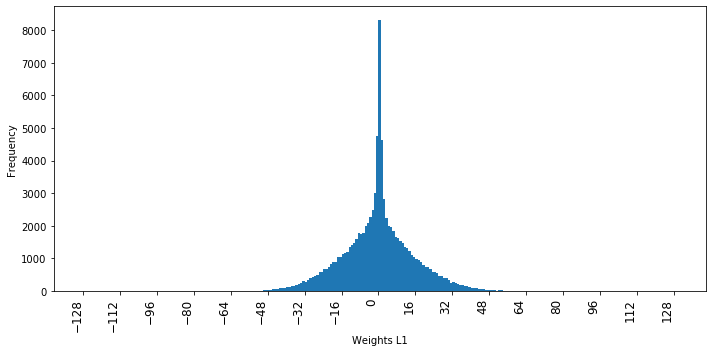

Weights L2 sparsity:
total values  4096
zero values  57
  max weight: 0.531803
  min weight: -0.522982


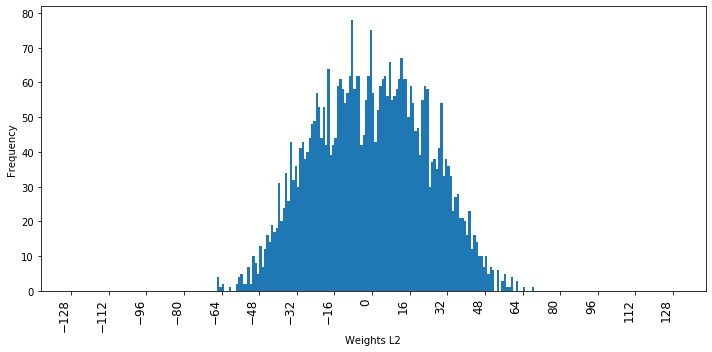

Linear layer sparsity:
total values  448
zero values  9
  max weight: 0.416899
  min weight: -0.446508


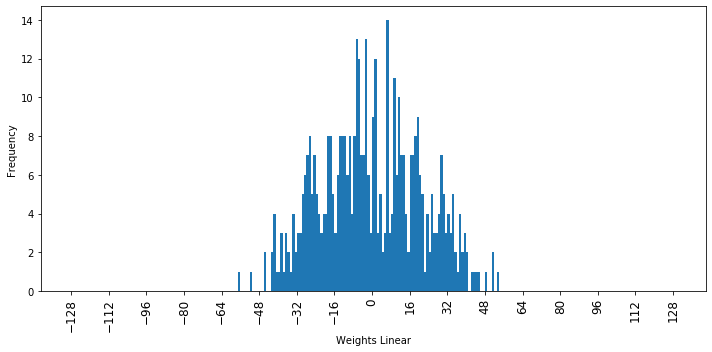

MAX FEA INTERNAL VALUE linear no acc: 0.000000
MIN FEA INTERNAL VALUE linear no acc: 0.000000
MAX FEA INTERNAL VALUE layer 1:       0.000000
MAX FEA INTERNAL VALUE layer 2:       0.000000


In [6]:
from matplotlib import pyplot as plt


def _plot_weight_hist(weights_tensor, title, w_qbits, w_s, w_z):
    """Quantise weights and plot their histogram."""
    mybins = list(range(-2**(w_qbits - 1), 2**(w_qbits - 1) + 2))
    y = sgrace.quantization_qbits(weights_tensor, w_s, w_z, w_qbits)
    y = y.reshape(1, -1)
    print(f"{title} sparsity:")
    sgrace.isSparse(y, y.shape[0], y.shape[1])
    print(f"  max weight: {torch.max(weights_tensor).item():.6f}")
    print(f"  min weight: {torch.min(weights_tensor).item():.6f}")
    plt.figure(figsize=(10, 5))
    plt.xlabel(title)
    plt.ylabel("Frequency")
    plt.hist(y.flatten(), mybins)
    plt.xticks(mybins[::max(1, len(mybins)//16)],
               horizontalalignment="right", fontsize=12, rotation=90)
    plt.tight_layout()
    plt.show()


# --- Layer 1 weights (graph conv) ---
_plot_weight_hist(model.conv1.weight.data,
                  "Weights L1", config.w_qbits, state.w_s, state.w_z)

# --- Layer 2 weights (graph conv) ---
_plot_weight_hist(model.conv2.weight.data,
                  "Weights L2", config.w_qbits, state.w_s2, state.w_z2)

# --- Linear classifier weights ---
mybins_l = list(range(-2**(config.w_qbitsl - 1), 2**(config.w_qbitsl - 1) + 2))
if config.total_layer_count == 3:
    lin_w = model.lin.weight_linear.data
    y_lin = sgrace.quantization_qbits(lin_w, state.w_sl, state.w_zl, config.w_qbitsl)
else:
    lin_w = model.lin.weight.data
    y_lin = lin_w
y_lin = y_lin.reshape(1, -1)
print("Linear layer sparsity:")
sgrace.isSparse(y_lin, y_lin.shape[0], y_lin.shape[1])
print(f"  max weight: {torch.max(lin_w).item():.6f}")
print(f"  min weight: {torch.min(lin_w).item():.6f}")
plt.figure(figsize=(10, 5))
plt.xlabel("Weights Linear")
plt.ylabel("Frequency")
plt.hist(y_lin.flatten(), mybins_l)
plt.xticks(mybins_l[::max(1, len(mybins_l)//16)],
           horizontalalignment="center", fontsize=12, rotation=90)
plt.tight_layout()
plt.show()

# --- Internal feature calibration values ---
print(f"MAX FEA INTERNAL VALUE linear no acc: {state.global_max_input:.6f}")
print(f"MIN FEA INTERNAL VALUE linear no acc: {state.global_min_input:.6f}")
print(f"MAX FEA INTERNAL VALUE layer 1:       {state.cur_max_fea:.6f}")
print(f"MAX FEA INTERNAL VALUE layer 2:       {state.cur_max_fea2:.6f}")